In [ ]:
# Prepared by Andrii Matsevytyi on 24.02.2025

In [1]:
# necessary imports

from diffusers import StableDiffusionInpaintPipeline
import torch
from PIL import Image
import matplotlib.pyplot as plt

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [ ]:
# load and prepare data

!gdown https://drive.google.com/uc?id=1teMMV7lxXotlzYqnt-a8-zn6nVYsYPFZ&export=download
!unzip /content/frames.zip

Archive:  /content/frames.zip
   creating: frames/
  inflating: __MACOSX/._frames       
  inflating: frames/.DS_Store        
  inflating: __MACOSX/frames/._.DS_Store  
   creating: frames/imgs/
  inflating: __MACOSX/frames/._imgs  
   creating: frames/masks/
  inflating: __MACOSX/frames/._masks  
  inflating: frames/imgs/110020220086_01.png  
  inflating: __MACOSX/frames/imgs/._110020220086_01.png  
  inflating: frames/imgs/110020220079_01.png  
  inflating: __MACOSX/frames/imgs/._110020220079_01.png  
  inflating: frames/imgs/110020234383_01.png  
  inflating: __MACOSX/frames/imgs/._110020234383_01.png  
  inflating: frames/imgs/190605067703_01.png  
  inflating: __MACOSX/frames/imgs/._190605067703_01.png  
  inflating: frames/imgs/190605021125_01.png  
  inflating: __MACOSX/frames/imgs/._190605021125_01.png  
  inflating: frames/masks/110020220086_01.png  
  inflating: __MACOSX/frames/masks/._110020220086_01.png  
  inflating: frames/masks/110020220079_01.png  
  inflating: __MACOS

In [13]:
# Load images
src_img = Image.open("/content/frames/imgs/110020220079_01.png").convert("RGB").resize((512, 512))  # Source object
bg_img = Image.open("/content/bg_1.jpg").convert("RGB").resize((512, 512))
mask_img = Image.open("/content/frames/masks/110020220079_01.png").convert("L").resize((512, 512))  # Black & white mask


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device = "mps" if torch.backends.mps.is_available() else device

# prepare stablediffusion pipe
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16
).to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/748 [00:00<?, ?B/s]

(…)ure_extractor%2Fpreprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

...

diffusion_pytorch_model.bin:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae%2Fconfig.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

diffusion_pytorch_model.bin:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


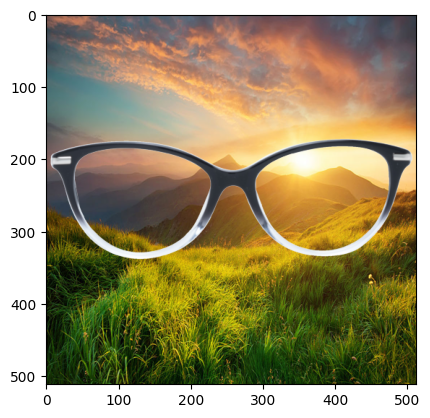

In [19]:
# Copy - paste images (step 1)
merged_img = Image.composite(src_img, bg_img, mask_img)

plt.imshow(merged_img)

In [4]:
def progress_callback(step, timestep, latents):
    """Prints progress at each inference step"""
    print(f"Step {step}, Timestep {timestep}")

In [22]:
# apply stable diffusion to make the blend look realistic (step 2)

blended_image = pipe(
    prompt="Make a realistic blend, remove the sharp edges, while preserving the glasses", # TODO: play around more with prompts
    image=merged_img,
    mask_image=mask_img,
    strength=0.75,
    guidance_scale=7.5
).images[0]

blended_image.save("final_blended_output.png")
blended_image.show()


  0%|          | 0/37 [00:00<?, ?it/s]

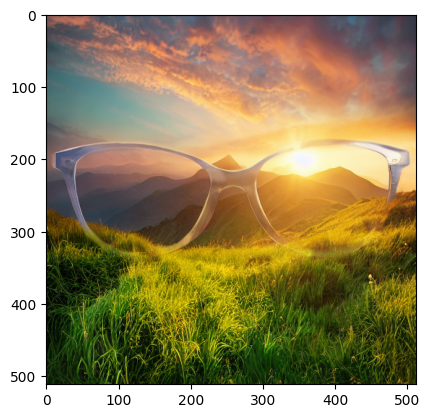

In [21]:
plt.imshow(blended_image)

# should look much different when applied to human face :)